# **Разработка модели оценки стоимости футбольных трансферов**

In [1]:
!pip install kagglehub -q

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import kagglehub

path = kagglehub.dataset_download("xfkzujqjvx97n/football-datasets")

def load_csv(file_path, description=""):
    full_path = os.path.join(path, file_path)
    df = pd.read_csv(full_path, low_memory=False)
    print(f"   {description:30}: {len(df):8,} rows, {len(df.columns):3d} cols")
    return df

transfer_history = load_csv('transfer_history/transfer_history.csv', "История трансферов")
player_profiles = load_csv('player_profiles/player_profiles.csv', "Профили игроков")
market_values = load_csv('player_market_value/player_market_value.csv', "Рыночная стоимость")
player_performances = load_csv('player_performances/player_performances.csv', "Выступления игроков")
player_injuries = load_csv('player_injuries/player_injuries.csv', "Травмы игроков")
player_national = load_csv('player_national_performances/player_national_performances.csv', "Сборная")

100%|██████████| 81.4M/81.4M [00:00<00:00, 175MB/s]

Extracting files...


   История трансферов            : 1,101,440 rows,  10 cols
   Профили игроков               :   92,671 rows,  34 cols
   Рыночная стоимость            :  901,429 rows,   3 cols
   Выступления игроков           : 1,878,719 rows,  20 cols
   Травмы игроков                :  143,195 rows,   7 cols
   Сборная                       :   92,701 rows,   9 cols


In [2]:
def extract_season_year(season):
    if pd.isna(season):
        return None
    s = str(season).strip()
    if '/' in s:
        first = s.split('/')[0]
        if len(first) == 4:
            return int(first)
        elif len(first) == 2:
            return 2000 + int(first) if int(first) < 50 else 1900 + int(first)
    if s.isdigit() and len(s) == 4:
        return int(s)
    return None

def get_age_group(age):
    if pd.isna(age):
        return 'Unknown'
    if age < 20:
        return '<20'
    elif age < 24:
        return '20-24'
    elif age < 28:
        return '24-27'
    elif age < 31:
        return '27-30'
    elif age < 34:
        return '30-33'
    elif age < 37:
        return '33-37'
    else:
        return '37+'

def calculate_advanced_metrics(df_perf):
    df = df_perf.copy()
    if 'goals' in df.columns and 'assists' in df.columns and 'minutes_played' in df.columns:
        df['goals_assists_per_90'] = (df['goals'] + df['assists']) / (df['minutes_played'] / 90 + 1e-5)
        df['goals_assists_per_90'] = df['goals_assists_per_90'].replace([np.inf, -np.inf], 0).fillna(0)
    if 'penalty_goals' in df.columns and 'goals' in df.columns:
        df['non_penalty_goals'] = df['goals'] - df['penalty_goals'].fillna(0)
    if 'clean_sheets' in df.columns and 'goals_conceded' in df.columns:
        df['clean_sheet_ratio'] = df['clean_sheets'] / (df['goals_conceded'] + 1)
    return df

In [3]:
df_transfers = transfer_history[transfer_history['transfer_fee'] > 0].copy()
df_transfers['log_fee'] = np.log1p(df_transfers['transfer_fee'])
df_transfers['season_year'] = df_transfers['season_name'].apply(extract_season_year)
df_transfers = df_transfers.dropna(subset=['transfer_date', 'player_id'])

player_profiles['birth_date'] = pd.to_datetime(player_profiles['date_of_birth'], errors='coerce')
df_transfers['transfer_date'] = pd.to_datetime(df_transfers['transfer_date'], errors='coerce')

# Объединение с профилями
df = df_transfers.merge(
    player_profiles[['player_id', 'birth_date', 'position', 'height', 'foot']],
    on='player_id', how='left'
)

# Расчёт возраста
df['age'] = (df['transfer_date'] - df['birth_date']).dt.days / 365.25
df['age'] = df['age'].round(0)
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
df['age_squared'] = df['age'] ** 2
df['age_group'] = df['age'].apply(get_age_group)

In [4]:
market_values['date_unix'] = pd.to_datetime(market_values['date_unix'], errors='coerce')
market_values = market_values[market_values['value'] > 0]
df = df.sort_values('transfer_date')
market_values = market_values.sort_values('date_unix')

df = pd.merge_asof(
    df, market_values[['player_id', 'date_unix', 'value']],
    left_on='transfer_date', right_on='date_unix', by='player_id',
    direction='backward', tolerance=pd.Timedelta('365D')
)
df = df.rename(columns={'value': 'market_value'})
df['has_market_value'] = df['market_value'].notna()
df['temp_age_group'] = pd.cut(df['age'], bins=[0, 22, 27, 32, 100], labels=['young', 'prime', 'peak', 'veteran'])

# Заполнение пропусков медианой по группе (позиция + возрастная группа)
market_value_medians = df[df['has_market_value']].groupby(['position', 'temp_age_group'])['market_value'].median().to_dict()
for idx, row in df[~df['has_market_value']].iterrows():
    key = (row['position'], row['temp_age_group'])
    if key in market_value_medians and not pd.isna(market_value_medians[key]):
        df.loc[idx, 'market_value'] = market_value_medians[key]
    else:
        df.loc[idx, 'market_value'] = df[df['has_market_value']]['market_value'].median()

df['market_value_log'] = np.log1p(df['market_value'])
df = df.drop(columns=['temp_age_group'])

/tmp/ipykernel_11388/3893631416.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  market_value_medians = df[df['has_market_value']].groupby(['position', 'temp_age_group'])['market_value'].median().to_dict()


In [5]:
player_performances['season_year'] = player_performances['season_name'].apply(extract_season_year)

ALL_STATS = ['goals','assists','minutes_played','yellow_cards','direct_red_cards',
             'second_yellow_cards','own_goals','penalty_goals','goals_conceded','clean_sheets']

agg_dict = {stat:'sum' for stat in ALL_STATS if stat in player_performances.columns}
player_performances = calculate_advanced_metrics(player_performances)
advanced_metrics = ['goals_assists_per_90','non_penalty_goals','clean_sheet_ratio']
for metric in advanced_metrics:
    if metric in player_performances.columns:
        agg_dict[metric] = 'mean'

perf_agg = player_performances.groupby(['player_id','season_year']).agg(agg_dict).reset_index()
stat_columns = list(agg_dict.keys())

stats = []
missing_stats = 0
for idx, row in df.iterrows():
    player_stats = perf_agg[
        (perf_agg['player_id'] == row['player_id']) &
        (perf_agg['season_year'] >= row['season_year'] - 2) &
        (perf_agg['season_year'] < row['season_year'])
    ]
    row_stats = {}
    if len(player_stats) == 0:
        missing_stats += 1
        for stat in stat_columns:
            row_stats[stat] = 0
    else:
        for stat in stat_columns:
            if stat in ['goals_assists_per_90','clean_sheet_ratio']:
                row_stats[stat] = player_stats[stat].mean()
            else:
                row_stats[stat] = player_stats[stat].sum()
    stats.append(row_stats)

stats_df = pd.DataFrame(stats)
for col in stats_df.columns:
    df[f'{col}_last_2y'] = stats_df[col]

In [6]:
player_injuries['from_date'] = pd.to_datetime(player_injuries['from_date'], errors='coerce')
injury_stats = []
for idx, row in df.iterrows():
    inj = player_injuries[
        (player_injuries['player_id'] == row['player_id']) &
        (player_injuries['from_date'] <= row['transfer_date'])
    ]
    injury_stats.append(inj['days_missed'].sum())
df['injury_days'] = injury_stats

# Национальная сборная
agg_dict_national = {'goals': 'sum'}
for col in player_national.columns:
    if col not in ['player_id', 'season', 'season_name', 'date'] and col not in agg_dict_national:
        if player_national[col].dtype in ['int64', 'float64']:
            agg_dict_national[col] = 'sum'

national_agg = player_national.groupby('player_id').agg(agg_dict_national).reset_index()
rename_dict = {col: f'national_{col}' if col != 'goals' else 'national_goals' for col in agg_dict_national.keys()}
national_agg = national_agg.rename(columns=rename_dict)
df = df.merge(national_agg, on='player_id', how='left')
for col in rename_dict.values():
    if col in df.columns:
        df[col] = df[col].fillna(0)

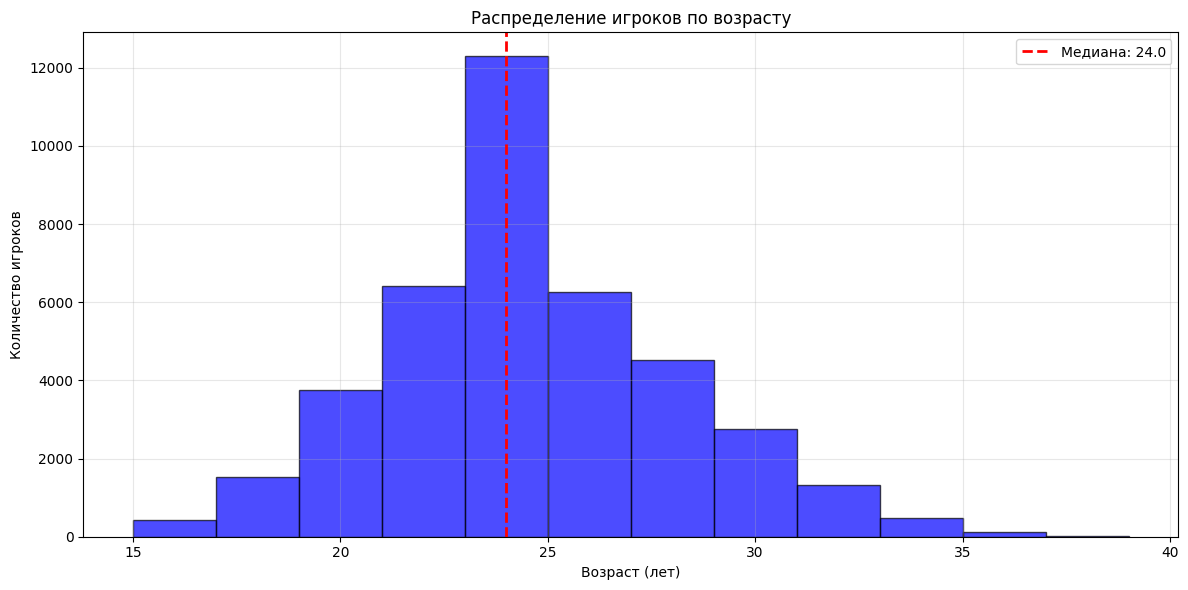

In [7]:
# Распределение по возрасту
plt.figure(figsize=(12,6))
age_bins = np.arange(15, 41, 2)
plt.hist(df['age'], bins=age_bins, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(x=df['age'].median(), color='red', linestyle='--', linewidth=2,
              label=f"Медиана: {df['age'].median():.1f}")
plt.xlabel('Возраст (лет)')
plt.ylabel('Количество игроков')
plt.title('Распределение игроков по возрасту')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

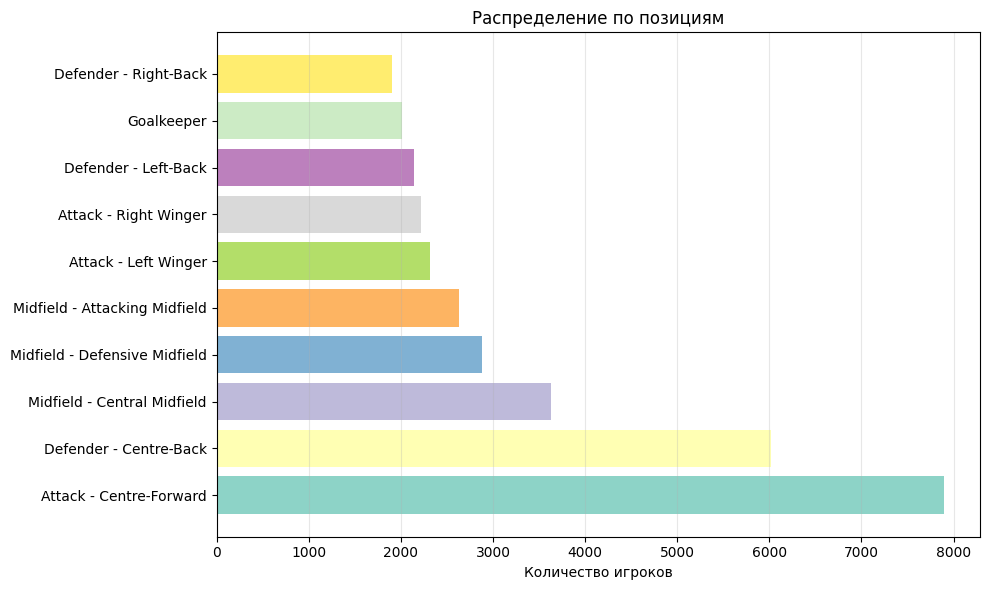

In [8]:
# Распределение по позициям
plt.figure(figsize=(10,6))
position_counts = df['position'].value_counts().head(10)
colors = plt.cm.Set3(np.linspace(0, 1, len(position_counts)))
plt.barh(position_counts.index, position_counts.values, color=colors)
plt.xlabel('Количество игроков')
plt.title('Распределение по позициям')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

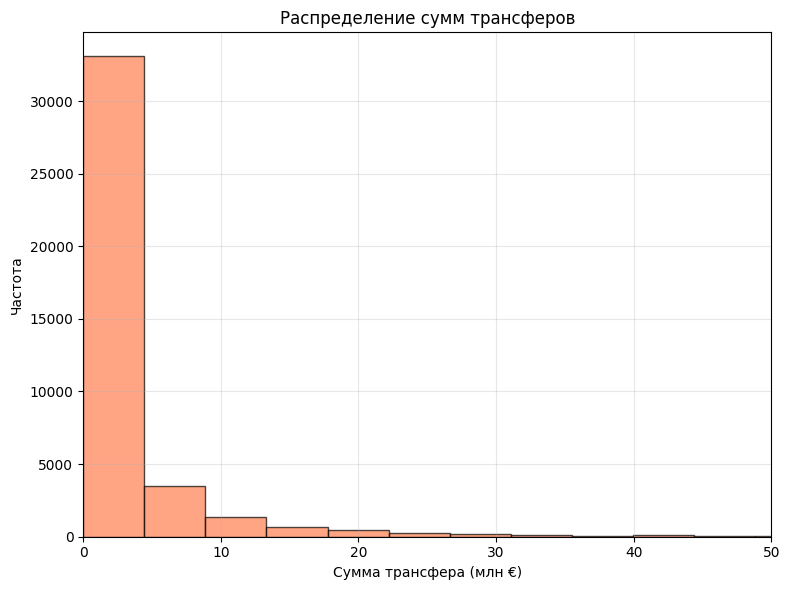

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# Распределение стоимости трансферов
fee_millions = df['transfer_fee'] / 1_000_000
ax.hist(fee_millions, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Сумма трансфера (млн €)')
ax.set_ylabel('Частота')
ax.set_title('Распределение сумм трансферов')
ax.set_xlim([0, 50])
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

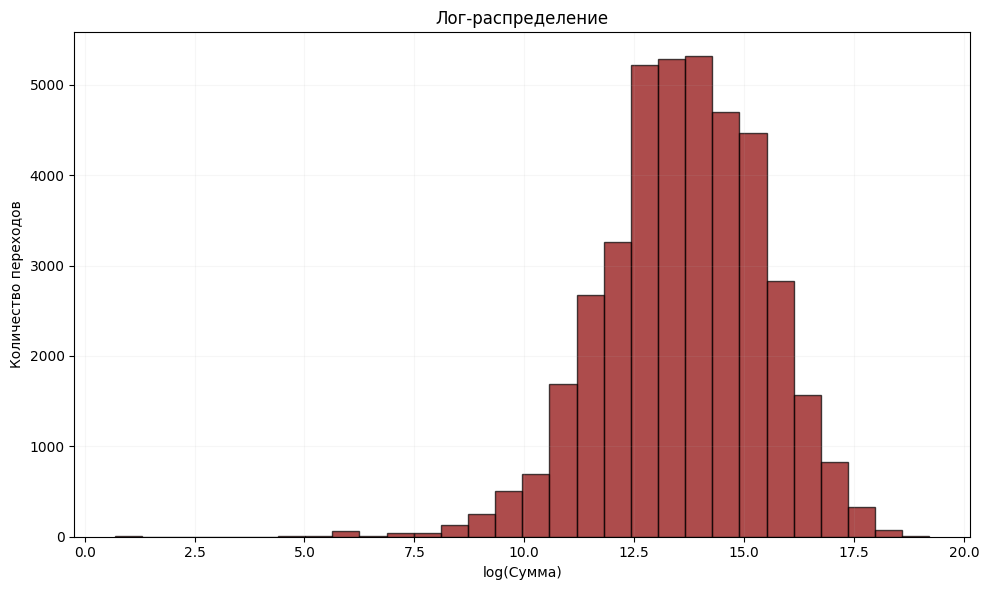

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Логарифмическим распределением
ax.hist(np.log1p(df['transfer_fee']), bins=30, color='darkred', edgecolor='black', alpha=0.7)
ax.set_xlabel('log(Сумма)')
ax.set_ylabel('Количество переходов')
ax.set_title('Лог-распределение')
ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11388/2080224687.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_avg = df.groupby('age_group_simple')['transfer_fee'].mean() / 1_000_000


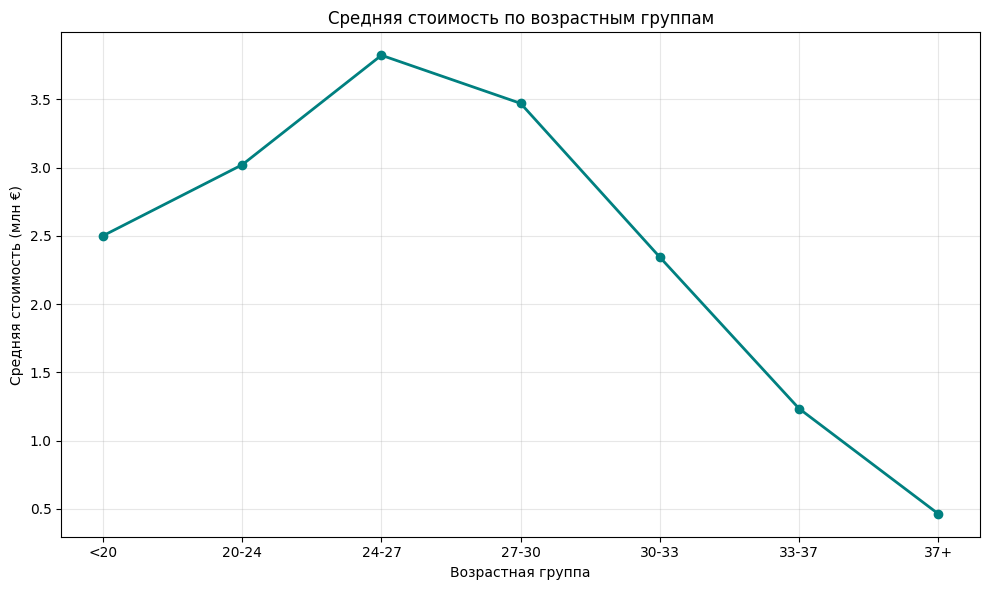

In [11]:
# Средняя стоимость по возрастным группам
age_groups = ['<20', '20-24', '24-27', '27-30', '30-33', '33-37', '37+']
df['age_group_simple'] = pd.cut(df['age'], bins=[0, 20, 24, 27, 30, 33, 37, 50], labels=age_groups)
age_group_avg = df.groupby('age_group_simple')['transfer_fee'].mean() / 1_000_000
plt.figure(figsize=(10,6))
plt.plot(age_group_avg.index, age_group_avg.values, marker='o', color='teal', linewidth=2)
plt.xlabel('Возрастная группа')
plt.ylabel('Средняя стоимость (млн €)')
plt.title('Средняя стоимость по возрастным группам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

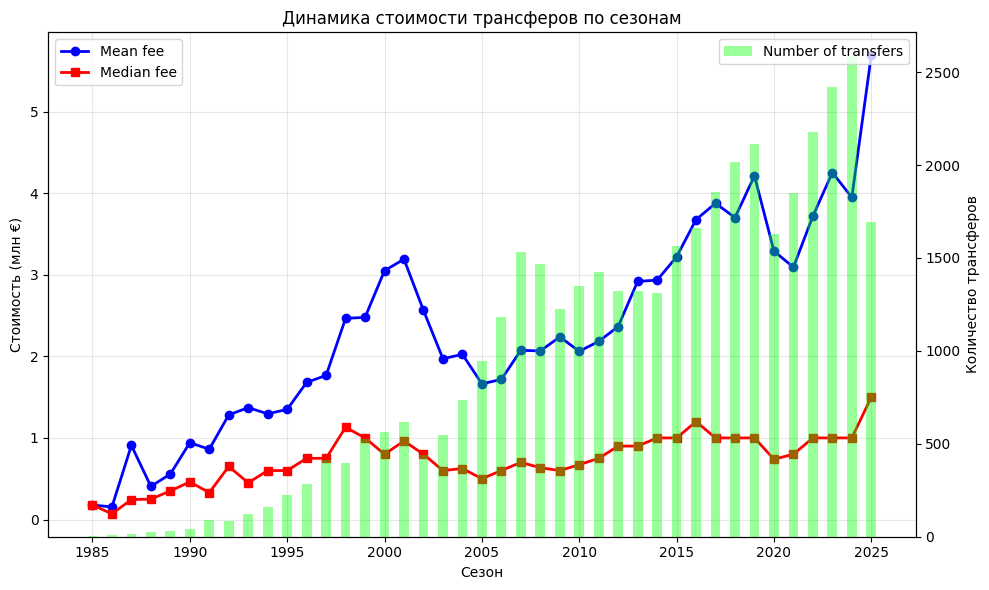

In [12]:
# Динамика по сезонам
season_stats = df.groupby('season_year').agg({'transfer_fee': ['mean', 'median', 'count']}).round(0)
season_stats.columns = ['mean_fee', 'median_fee', 'count']
season_stats = season_stats[(season_stats.index >= 1985) & (season_stats.index <= 2025)]

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(season_stats.index, season_stats['mean_fee'] / 1_000_000, marker='o', linewidth=2, markersize=6, color='blue', label='Mean fee')
ax.plot(season_stats.index, season_stats['median_fee'] / 1_000_000, marker='s', linewidth=2, markersize=6, color='red', label='Median fee')
ax.set_xlabel('Сезон')
ax.set_ylabel('Стоимость (млн €)')
ax.set_title('Динамика стоимости трансферов по сезонам')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

ax2 = ax.twinx()
ax2.bar(season_stats.index, season_stats['count'], alpha=0.4, color='lime', width=0.5, label='Number of transfers')
ax2.set_ylabel('Количество трансферов')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [13]:
performance_cols = [col for col in df.columns if col.endswith('_last_2y')]
df['position_simple'] = df['position'].fillna('Unknown').apply(lambda x: x.split('-')[0] if pd.notna(x) and '-' in str(x) else str(x))

FEATURES = [
    'age', 'age_squared', 'market_value', 'market_value_log',
    'injury_days', 'national_goals', 'national_matches'
] + performance_cols

# Фильтровать только существующие столбцы
available_features = [f for f in FEATURES if f in df.columns]
# Удалите national_matches, если он не нужен
if 'national_matches' not in df.columns:
    available_features = [f for f in available_features if f != 'national_matches']

# Убедитесь, что в df указана дата передачи
df['transfer_date'] = pd.to_datetime(df['transfer_date'])  # уже должно быть datetime, но на всякий случай

df_model = df[available_features + ['log_fee', 'season_year', 'transfer_fee', 'position_simple', 'transfer_date', 'player_id']].copy()

# Импутация пропусков
for col in available_features:
    if col in df_model.columns:
        if df_model[col].dtype in ['int64', 'float64']:
            median_val = df_model[col].median()
            df_model[col] = df_model[col].fillna(median_val)
        else:
            mode_val = df_model[col].mode()[0] if not df_model[col].mode().empty else 'Unknown'
            df_model[col] = df_model[col].fillna(mode_val)

print(f"Финальный размер датасет: {len(df_model)} записей, {len(available_features)} признаков")

Финальный размер датасет: 39997 записей, 20 признаков


In [14]:
train = df_model[df_model['transfer_date'].dt.year <= 2021]
test = df_model[df_model['transfer_date'].dt.year > 2021]

X_train = train[available_features]
y_train = train['log_fee']
X_test = test[available_features]
y_test = test['log_fee']

# Для реальных сумм (обратное преобразование)
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 30447, Test size: 9550


In [15]:
tscv = TimeSeriesSplit(n_splits=5)

# Ridge
ridge_params = {'alpha': [1.0, 10.0, 50.0]}
ridge_grid = GridSearchCV(Ridge(random_state=42, max_iter=1000), ridge_params,
                          cv=tscv, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_
print(f"Best Ridge alpha: {ridge_grid.best_params_}")

# Lasso
lasso_params = {'alpha': [0.001, 0.01, 0.1]}
lasso_grid = GridSearchCV(Lasso(random_state=42, max_iter=1000), lasso_params,
                          cv=tscv, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)
best_lasso = lasso_grid.best_estimator_
print(f"Best Lasso alpha: {lasso_grid.best_params_}")

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20],
    'min_samples_split': [5, 10]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_params,
                       cv=tscv, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")

# Gradient Boosting
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42, subsample=0.8), gb_params,
                       cv=tscv, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
print(f"Best GB params: {gb_grid.best_params_}")

Best Ridge alpha: {'alpha': 50.0}
Best Lasso alpha: {'alpha': 0.01}
Best RF params: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}
Best GB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


In [20]:
models = {
    'Ridge (L2)': best_ridge,
    'Lasso (L1)': best_lasso,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb
}

results_train = []
results_test = []
best_model = None
best_r2_test = -np.inf

for name, model in models.items():
    print(f"\nОбучение: {name}")
    if name in ['Ridge (L2)', 'Lasso (L1)']:
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

    y_pred_train_real = np.expm1(y_pred_train)
    y_pred_test_real = np.expm1(y_pred_test)

    mae_train = mean_absolute_error(y_train_real, y_pred_train_real)
    r2_train = r2_score(y_train_real, y_pred_train_real)
    mape_train = mean_absolute_percentage_error(y_train_real, y_pred_train_real)

    mae_test = mean_absolute_error(y_test_real, y_pred_test_real)
    r2_test = r2_score(y_test_real, y_pred_test_real)
    mape_test = mean_absolute_percentage_error(y_test_real, y_pred_test_real)

    results_train.append({'Model': name, 'MAE_train (€)': mae_train, 'R2_train': r2_train, 'MAPE_train (%)': mape_train})
    results_test.append({'Model': name, 'MAE_test (€)': mae_test, 'R2_test': r2_test, 'MAPE_test (%)': mape_test})

    print(f"   Train: MAE = €{mae_train:,.0f}, R² = {r2_train:.4f}, MAPE = {mape_train:.1f}%")
    print(f"   Test : MAE = €{mae_test:,.0f}, R² = {r2_test:.4f}, MAPE = {mape_test:.1f}%")

    if r2_test > best_r2_test:
        best_r2_test = r2_test
        best_model = model
        best_model_name = name

print(f"\nЛучшая модель на тесте: {best_model_name} (R² = {best_r2_test:.4f})")


Обучение: Ridge (L2)
   Train: MAE = €2,338,962, R² = -14.8802, MAPE = 29.3%
   Test : MAE = €3,103,832, R² = -14.3914, MAPE = 41.8%

Обучение: Lasso (L1)
   Train: MAE = €2,239,226, R² = -11.5699, MAPE = 32.3%
   Test : MAE = €2,864,391, R² = -8.1105, MAPE = 39.7%

Обучение: Random Forest
   Train: MAE = €1,101,130, R² = 0.8276, MAPE = 7.5%
   Test : MAE = €1,772,882, R² = 0.7808, MAPE = 42.5%

Обучение: Gradient Boosting
   Train: MAE = €1,423,874, R² = 0.7059, MAPE = 13.7%
   Test : MAE = €1,787,537, R² = 0.7632, MAPE = 49.3%

Лучшая модель на тесте: Random Forest (R² = 0.7808)



Топ-10 важнейших признаков (feature_importances_):
    4. market_value_log                   : 0.3212 (32.1%)
    3. market_value                       : 0.2762 (27.6%)
    7. national_matches                   : 0.1073 (10.7%)
   11. yellow_cards_last_2y               : 0.0446 (4.5%)
   10. minutes_played_last_2y             : 0.0401 (4.0%)
    1. age                                : 0.0289 (2.9%)
    2. age_squared                        : 0.0282 (2.8%)
   18. goals_assists_per_90_last_2y       : 0.0259 (2.6%)
    9. assists_last_2y                    : 0.0239 (2.4%)
    6. national_goals                     : 0.0221 (2.2%)


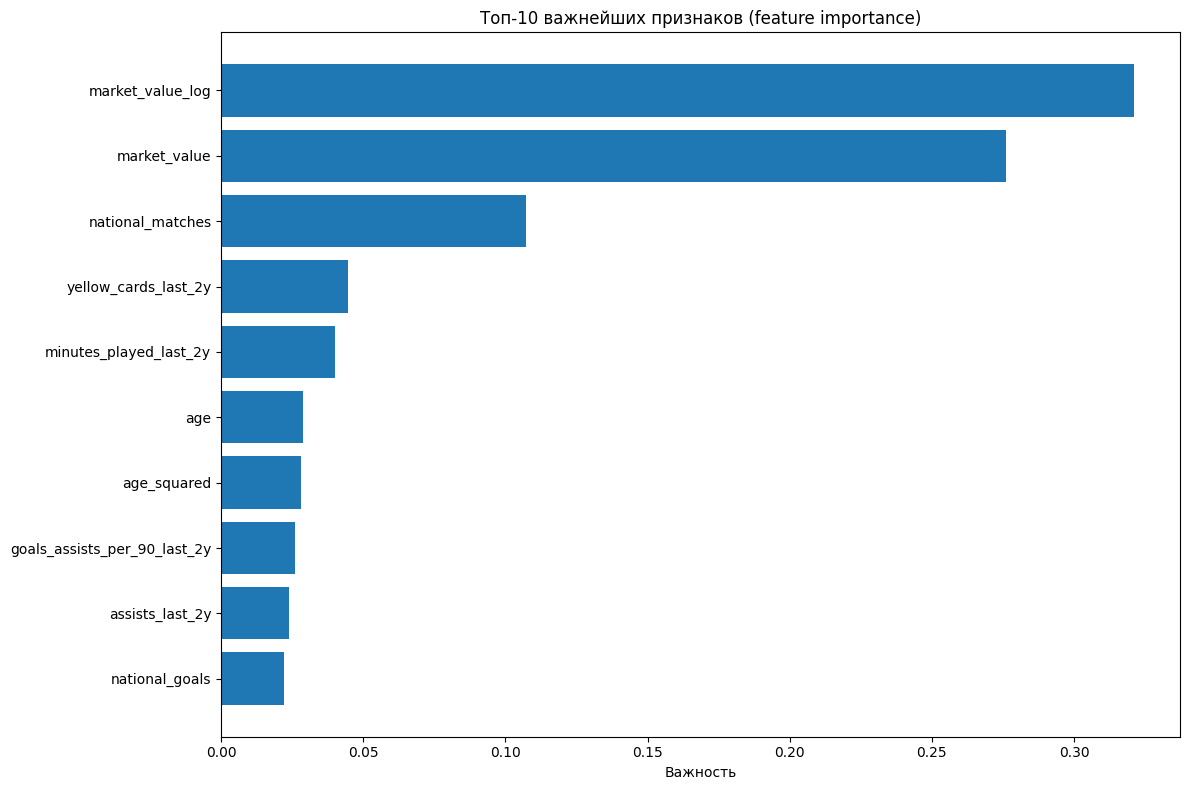


Permutation importance анализ...
Топ-10 по permutation importance:
    4. market_value_log                   : 0.3452 ± 0.0078
    3. market_value                       : 0.2856 ± 0.0065
    7. national_matches                   : 0.0178 ± 0.0019
    2. age_squared                        : 0.0110 ± 0.0009
    5. injury_days                        : 0.0104 ± 0.0024
    1. age                                : 0.0104 ± 0.0009
   19. non_penalty_goals_last_2y          : 0.0067 ± 0.0013
   11. yellow_cards_last_2y               : 0.0064 ± 0.0015
    8. goals_last_2y                      : 0.0047 ± 0.0009
    9. assists_last_2y                    : 0.0024 ± 0.0006


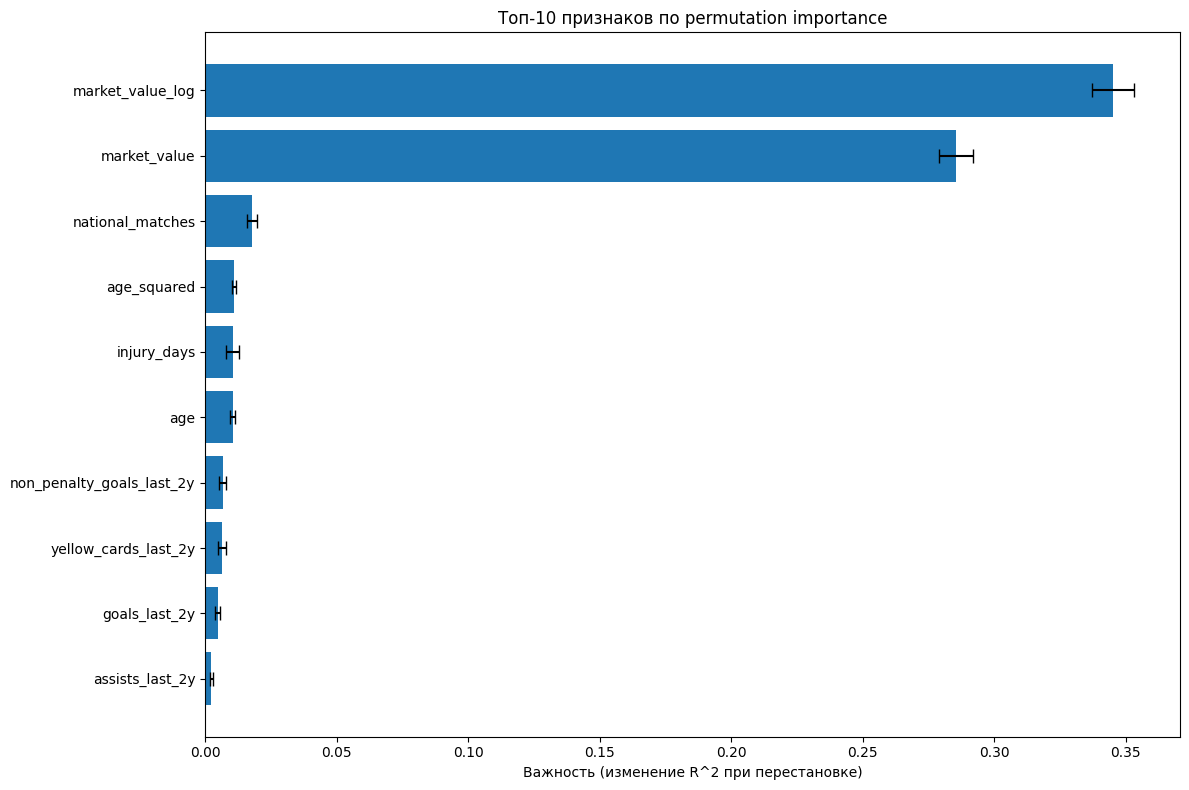

In [21]:
# Анализ важности признаков

# Определяем, с какими данными работаем
use_scaled = 'Ridge' in best_model_name or 'Lasso' in best_model_name
X_test_best = X_test_scaled if use_scaled else X_test

# Встроенная важность для древовидных моделей
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Признак': available_features,
        'Важность': best_model.feature_importances_
    }).sort_values('Важность', ascending=False)

    print("\nТоп-10 важнейших признаков (feature_importances_):")
    for i, row in importance.head(10).iterrows():
        print(f"   {i+1:2d}. {row['Признак']:35s}: {row['Важность']:.4f} ({row['Важность']*100:.1f}%)")

    # Визуализация
    plt.figure(figsize=(12, 8))
    plt.barh(importance['Признак'].head(10), importance['Важность'].head(10))
    plt.xlabel('Важность')
    plt.title('Топ-10 важнейших признаков (feature importance)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


# Permutation importance (для всех моделей)
print("\nPermutation importance анализ...")
perm = permutation_importance(
    best_model, X_test_best, y_test,
    n_repeats=10, random_state=42, scoring='r2', n_jobs=-1
)

perm_importance = pd.DataFrame({
    'Признак': available_features,
    'Важность': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Важность', ascending=False)

print("Топ-10 по permutation importance:")
for i, row in perm_importance.head(10).iterrows():
    print(f"   {i+1:2d}. {row['Признак']:35s}: {row['Важность']:.4f} ± {row['Std']:.4f}")

# Визуализация permutation importance
plt.figure(figsize=(12, 8))
plt.barh(perm_importance['Признак'].head(10), perm_importance['Важность'].head(10),
         xerr=perm_importance['Std'].head(10), capsize=5)
plt.xlabel('Важность (изменение R^2 при перестановке)')
plt.title('Топ-10 признаков по permutation importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Анализ конкретных трансферов

def find_player(player_name):
    # Поиск игрока по имени в профилях
    if player_profiles.empty:
        print("   Данные профилей не загружены")
        return None

    matches = player_profiles[
        player_profiles['player_name'].str.contains(player_name, case=False, na=False)
    ]

    if len(matches) == 0:
        print(f"   Игрок '{player_name}' не найден")
        return None

    print(f"   Найдено {len(matches)} совпадений:")
    for i, (_, row) in enumerate(matches.iterrows()):
        print(f"      {i+1}. {row['player_name']} (ID: {row['player_id']})")

    return matches.iloc[0]

def analyze_player_transfer(player_id, target_year):
    # Анализ конкретного трансфера игрока

    # Поиск трансфера
    transfer = df[
        (df['player_id'] == player_id) &
        (df['season_year'] == target_year)
    ]

    if len(transfer) == 0:
        print(f"   Трансфер {target_year} года не найден")

        # Показываем доступные трансферы
        player_transfers = df[df['player_id'] == player_id].sort_values('season_year')
        if len(player_transfers) > 0:
            print("   Доступные трансферы:")
            for _, t in player_transfers.iterrows():
                from_team = t.get('from_team_name', 'Unknown')
                to_team = t.get('to_team_name', 'Unknown')
                print(f"      • {t['season_year']}: {from_team} → {to_team} (€{t['transfer_fee']:,.0f})")
        return None

    data = transfer.iloc[0]

    # Формируем признаки для модели
    profile_data = {}
    for feat in available_features:
        profile_data[feat] = data.get(feat, 0)

    profile = pd.DataFrame([profile_data])[available_features]

    # Масштабирование для линейных моделей
    if use_scaled:
        profile_scaled = scaler.transform(profile)
        pred_log = best_model.predict(profile_scaled)[0]
    else:
        pred_log = best_model.predict(profile)[0]

    pred_value = np.expm1(pred_log)
    actual = data['transfer_fee']

    if actual > 0:
        error_abs = abs(actual - pred_value)
        error_pct = ((error_abs / actual) * 100)
    else:
        error_abs = 0
        error_pct = 0

    # Получаем имя игрока
    player_info = player_profiles[player_profiles['player_id'] == player_id]
    player_name = player_info.iloc[0]['player_name'] if len(player_info) > 0 else "Неизвестно"

    # Детальный вывод
    print(f"Анализ трансфера: {player_name}")
    print(f"   Год трансфера:    {data['season_year']}")
    print(f"   Возраст:          {data['age']:.1f} лет")
    print(f"   Позиция:          {data.get('position', 'Unknown')}")
    print(f"   Фактическая сумма: €{actual:,.0f} (€{actual/1_000_000:.2f}M)")
    print(f"   Прогноз модели:    €{pred_value:,.0f} (€{pred_value/1_000_000:.2f}M)")
    print(f"   Абсолютная ошибка: €{error_abs:,.0f}")
    print(f"   Относительная ошибка: {error_pct:.1f}%")


    return {
        'player_name': player_name,
        'season': data['season_year'],
        'age': data['age'],
        'position': data.get('position', 'Unknown'),
        'actual_fee': actual,
        'predicted_fee': pred_value,
        'error_abs': error_abs,
        'error': error_pct
    }

players_to_analyze = [
    ("Karim Benzema", 2009),
    ("Zlatan Ibrahimović", 2011),
    ("Antoine Griezmann", 2019),
    ("Luis Suárez", 2022),
    ("Kristjan Asllani", 2023),
    ("Arnau Tenas", 2025)
]

case_studies = []

print("Анализ известных трансферов")

for player_name, year in players_to_analyze:
    print(f"\nПоиск: {player_name} ({year})")
    player = find_player(player_name)

    if player is not None:
        result = analyze_player_transfer(player['player_id'], year)
        if result is not None:
            case_studies.append(result)

# Сводная таблица кейсов
case_df = pd.DataFrame(case_studies)
print("\nСводная таблица результатов анализа")

# Форматирование для вывода
display_df = case_df.copy()
display_df['actual_fee'] = display_df['actual_fee'].apply(lambda x: f"€{x/1_000_000:.1f}M")
display_df['predicted_fee'] = display_df['predicted_fee'].apply(lambda x: f"€{x/1_000_000:.1f}M")
display_df['error'] = display_df['error'].apply(lambda x: f"{x:.1f}%")

print(display_df[['player_name', 'season', 'actual_fee', 'predicted_fee', 'error']].to_string(index=False))

Анализ известных трансферов

Поиск: Karim Benzema (2009)
   Найдено 1 совпадений:
      1. Karim Benzema (18922) (ID: 18922)
Анализ трансфера: Karim Benzema (18922)
   Год трансфера:    2009
   Возраст:          22.0 лет
   Позиция:          Attack - Centre-Forward
   Фактическая сумма: €35,000,000 (€35.00M)
   Прогноз модели:    €31,938,168 (€31.94M)
   Абсолютная ошибка: €3,061,832
   Относительная ошибка: 8.7%

Поиск: Zlatan Ibrahimović (2011)
   Найдено 1 совпадений:
      1. Zlatan Ibrahimović (3455) (ID: 3455)
Анализ трансфера: Zlatan Ibrahimović (3455)
   Год трансфера:    2011
   Возраст:          30.0 лет
   Позиция:          Attack - Centre-Forward
   Фактическая сумма: €24,000,000 (€24.00M)
   Прогноз модели:    €22,700,202 (€22.70M)
   Абсолютная ошибка: €1,299,798
   Относительная ошибка: 5.4%

Поиск: Antoine Griezmann (2019)
   Найдено 1 совпадений:
      1. Antoine Griezmann (125781) (ID: 125781)
Анализ трансфера: Antoine Griezmann (125781)
   Год трансфера:    2019
   В